In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from pathlib import Path

# -----------------------------------------------------------------------------
# DATA
# -----------------------------------------------------------------------------
DATA_PATH = Path("data_jakob_lena_felix_clean.csv")
df = pd.read_csv(DATA_PATH)

# -----------------------------------------------------------------------------
# GLOBAL CONFIG
# -----------------------------------------------------------------------------
ALL_VEH = ["motorrad", "pkw", "pkw_an", "lkw", "bus", "lz_slz"]

VEHICLE_MOVEMENTS = {
    "W_E": "hoettinger_au_west_ost",
    "W_S": "hoettinger_au_west_süd",
    "E_W": "hoettinger_au_ost_west",
    "E_S": "hoettinger_au_ost_sued",
    "S_W": "hoettinger_au_sued_west",
    "S_E": "hoettinger_au_sued_ost",
}

PED_SEGMENTS = {
    "Roesslsteig -> Insel": {
        "location": "roesslsteig_insel",
        "start": (2.0, 3.0),
        "end": (2.0, -2.0),
        "include_bikes": True,
    },
    "Insel -> Haltestelle": {
        "location": "zebra_ost_west_bis_Bahnhaltestelle",
        "start": (2.0, -2.0),
        "end": (0.0, -2.0),
        "include_bikes": False,
    },
    "Haltestelle -> West": {
        "location": "zebra_ost_west_von_Bahnhaltestelle_nach_west",
        "start": (0.0, -2.0),
        "end": (-4.0, -3.0),
        "include_bikes": False,
    },
    "Insel -> Ost": {
        "location": "zebra_west_ost",
        "start": (2.0, -2.0),
        "end": (4.0, -3.0),
        "include_bikes": False,
    },
}

# Shared coordinate system for all plots
X_LIM = (-8.0, 8.0)
Y_LIM = (-8.0, 4.0)

# Vehicle geometry
LANE = 0.6
ARM = 6.0
SX = 0.0
P_IN = {"W": (-ARM, -LANE), "E": (ARM, LANE), "S": (SX + LANE, -ARM)}
P_OUT = {"W": (-ARM, LANE), "E": (ARM, -LANE), "S": (SX - LANE, -ARM)}

# Colors
COL_BG = "#ffffff"
COL_EDGE = "#1a1a1a"
COL_TEXT = "#1f1f1f"
COL_VEH = "#f2c94c"
PED_COLORS = ["#2e7d32", "#388e3c", "#4caf50", "#66bb6a"]


# -----------------------------------------------------------------------------
# GEOMETRY HELPERS
# -----------------------------------------------------------------------------
def quadbez(p0, p1, p2, n=140):
    t = np.linspace(0.0, 1.0, n)[:, None]
    return (1 - t) ** 2 * np.array(p0) + 2 * (1 - t) * t * np.array(p1) + t**2 * np.array(p2)


def straight_path(a, b, n=140):
    return np.linspace(a, b, n)


def turn_path(a, b, radius=2.0, direction="right", n=140):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    m = (a + b) / 2
    d = b - a
    norm = np.linalg.norm(d)
    if norm == 0:
        return np.repeat(a[None, :], n, axis=0)
    d = d / norm
    perp = np.array([-d[1], d[0]])
    if direction == "left":
        perp *= -1
    ctrl = m + perp * radius
    return quadbez(a, ctrl, b, n=n)


def vehicle_flow_paths():
    return {
        "W_E": straight_path(P_IN["W"], P_OUT["E"]),
        "E_W": straight_path(P_IN["E"], P_OUT["W"]),
        "W_S": turn_path(P_IN["W"], P_OUT["S"], radius=4.2, direction="right"),
        "E_S": turn_path(P_IN["E"], P_OUT["S"], radius=4.2, direction="left"),
        "S_W": turn_path(P_IN["S"], P_OUT["W"], radius=4.2, direction="left"),
        "S_E": turn_path(P_IN["S"], P_OUT["E"], radius=2.0, direction="right"),
    }


# -----------------------------------------------------------------------------
# DRAW HELPERS
# -----------------------------------------------------------------------------
def draw_flow_band(ax, path, volume, width, facecolor, edgecolor=COL_EDGE, zorder=5, draw_arrow=True):
    if volume <= 0:
        return

    tang = np.gradient(path, axis=0)
    norms = np.linalg.norm(tang, axis=1, keepdims=True)
    norms[norms == 0] = 1
    tang = tang / norms
    perp = np.column_stack([-tang[:, 1], tang[:, 0]])

    taper = np.linspace(1.0, 0.72, len(path))[:, None]
    w = width * taper

    left = path + perp * (w / 2)
    right = path - perp * (w / 2)
    poly = np.vstack([left, right[::-1]])

    ax.add_patch(
        Polygon(
            poly,
            closed=True,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=0.8,
            joinstyle="round",
            zorder=zorder,
        )
    )

    if draw_arrow:
        end_point = path[-1]
        end_dir = tang[-1]
        end_norm = np.linalg.norm(end_dir)
        if end_norm == 0:
            end_dir = np.array([1.0, 0.0])
        else:
            end_dir = end_dir / end_norm

        arrow_len = max(0.35, width * 1.5)
        arrow_headwidth = max(0.18, width * 0.9)

        ax.arrow(
            end_point[0] - end_dir[0] * arrow_len,
            end_point[1] - end_dir[1] * arrow_len,
            end_dir[0] * arrow_len,
            end_dir[1] * arrow_len,
            head_width=arrow_headwidth,
            head_length=arrow_len * 0.7,
            fc=facecolor,
            ec=edgecolor,
            alpha=0.95,
            zorder=zorder + 1,
            length_includes_head=True,
        )

    mid = path[len(path) // 2]
    ax.text(
        mid[0],
        mid[1],
        f"{int(volume)}",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=COL_TEXT,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
        zorder=zorder + 3,
    )


def style_common_axes(ax):
    ax.set_aspect("equal")
    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.set_facecolor(COL_BG)
    ax.axis("off")

    # Shared map context so both charts are spatially aligned.
    ax.plot([-ARM, ARM], [0, 0], color="lightgray", lw=1.3, linestyle="--", zorder=1)
    ax.plot([SX + 1.5, SX + 1.5], [-ARM, -0.5], color="lightgray", lw=1.3, linestyle="--", zorder=1)
    ax.plot([-4, 4], [-1, -1], color="lightgray", lw=0.8, linestyle=":", zorder=1)

    ax.text(-ARM - 0.3, 0, "Fuerstenweg West", ha="right", va="center", fontsize=10, weight="bold")
    ax.text(ARM + 0.3, 0, "Fuerstenweg Ost", ha="left", va="center", fontsize=10, weight="bold")
    ax.text(SX + 1.5, -ARM - 0.5, "Balsius Huber Strasse", ha="center", va="top", fontsize=10, weight="bold")

    ax.annotate(
        "",
        xy=(X_LIM[0] + 0.9, Y_LIM[1] - 0.6),
        xytext=(X_LIM[0] + 0.9, Y_LIM[1] - 1.4),
        arrowprops=dict(arrowstyle="->", lw=1.4, color="#333"),
    )
    ax.text(X_LIM[0] + 0.9, Y_LIM[1] - 0.4, "N", ha="center", va="bottom", weight="bold", fontsize=10)


def style_panel_axes(ax):
    ax.set_facecolor("#fcfcfc")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("#d0d0d0")


def time_label(times):
    if not times:
        return "all times"
    if len(times) == 1:
        return times[0]
    return f"{min(times)} - {max(times)}"


def normalize_times(frame, times):
    if times is None:
        return sorted(frame["time"].dropna().unique().tolist())
    if isinstance(times, str):
        return [times]
    return list(times)


def aggregate_location_volume(frame, location, times, cols):
    sub = frame[(frame["location"] == location) & (frame["time"].isin(times))]
    if sub.empty:
        return 0
    valid_cols = [c for c in cols if c in sub.columns]
    if not valid_cols:
        return 0
    return int(sub[valid_cols].fillna(0).to_numpy().sum())


def width_scaler(volumes, min_width, max_width):
    max_vol = max(volumes.values()) if any(volumes.values()) else 1

    def _scale(v):
        if v <= 0:
            return 0.0
        return min_width + (v / max_vol) * (max_width - min_width)

    return _scale


def draw_vehicle_layer(ax, frame, times, vehicles=None, min_width=0.12, max_width=0.8, z_base=5):
    if vehicles is None:
        vehicles = ALL_VEH
    if isinstance(vehicles, str):
        vehicles = [vehicles]

    flows = vehicle_flow_paths()
    vols = {k: aggregate_location_volume(frame, loc, times, vehicles) for k, loc in VEHICLE_MOVEMENTS.items()}
    width = width_scaler(vols, min_width, max_width)

    for key in sorted(flows.keys(), key=lambda k: vols[k]):
        v = vols[key]
        if v > 0:
            draw_flow_band(ax, flows[key], v, width(v), facecolor=COL_VEH, zorder=z_base)


def draw_pedestrian_layer(ax, frame, times, min_width=0.14, max_width=0.45, z_base=6):
    ped_vols = {}
    for name, info in PED_SEGMENTS.items():
        cols = ["fuß"]
        if info["include_bikes"]:
            cols.append("rad")
        ped_vols[name] = aggregate_location_volume(frame, info["location"], times, cols)

    width = width_scaler(ped_vols, min_width, max_width)

    for idx, (name, info) in enumerate(PED_SEGMENTS.items()):
        vol = ped_vols[name]
        if vol > 0:
            path = straight_path(info["start"], info["end"])
            draw_flow_band(
                ax,
                path,
                vol,
                width(vol),
                facecolor=PED_COLORS[idx % len(PED_COLORS)],
                zorder=z_base,
                draw_arrow=False,
            )

    ax.plot(2.0, -2.0, "s", markersize=7, color="#ffe082", markeredgecolor="#b97f00", zorder=z_base + 2)
    ax.text(2.0, -2.35, "Insel", ha="center", fontsize=8)

    ax.plot(0.0, -2.0, "^", markersize=7, color="#90caf9", markeredgecolor="#0d47a1", zorder=z_base + 2)
    ax.text(0.0, -2.35, "Haltestelle", ha="center", fontsize=8)

    ax.plot(2.0, 3.0, "o", markersize=8, color="#a5d6a7", markeredgecolor="#2e7d32", zorder=z_base + 2)
    ax.text(2.0, 3.35, "Roesslsteig", ha="center", fontsize=8, weight="bold")


# -----------------------------------------------------------------------------
# PLOT 1: VEHICLE FLOWS
# -----------------------------------------------------------------------------
def plot_vehicle_flows(frame, times=None, vehicles=None, ax=None, min_width=0.12, max_width=0.8, title=None):
    times = normalize_times(frame, times)

    created_fig = False
    if ax is None:
        created_fig = True
        fig, ax = plt.subplots(figsize=(11, 7.5))
    else:
        fig = ax.figure

    fig.patch.set_facecolor(COL_BG)
    style_common_axes(ax)
    draw_vehicle_layer(ax, frame, times, vehicles=vehicles, min_width=min_width, max_width=max_width)

    if title is None:
        title = "Kfz-Verkehrsstroeme"
    ax.set_title(f"{title}\nZeit: {time_label(times)}", fontsize=13, weight="bold", pad=12)

    if created_fig:
        plt.tight_layout()
         
    return fig


# -----------------------------------------------------------------------------
# PLOT 2: PEDESTRIAN FLOWS
# -----------------------------------------------------------------------------
def plot_pedestrian_flows(frame, times=None, ax=None, min_width=0.14, max_width=0.45, title=None):
    times = normalize_times(frame, times)

    created_fig = False
    if ax is None:
        created_fig = True
        fig, ax = plt.subplots(figsize=(11, 7.5))
    else:
        fig = ax.figurea

    fig.patch.set_facecolor(COL_BG)
    style_common_axes(ax)
    draw_pedestrian_layer(ax, frame, times, min_width=min_width, max_width=max_width)

    if title is None:
        title = "Fussgaengerstroeme"
    ax.set_title(f"{title}\nZeit: {time_label(times)}", fontsize=13, weight="bold", pad=12)

    if created_fig:
        plt.tight_layout()
         
    return fig



# -----------------------------------------------------------------------------
# PLOT 4: COMBINED OVERLAY (single panel, same axes)
# -----------------------------------------------------------------------------
def plot_combined_same_axes(frame, times=None, vehicles=None, figsize=(12, 8)):
    times = normalize_times(frame, times)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(COL_BG)

    style_common_axes(ax)
    draw_vehicle_layer(ax, frame, times, vehicles=vehicles, min_width=0.12, max_width=0.8, z_base=5)
    draw_pedestrian_layer(ax, frame, times, min_width=0.14, max_width=0.45, z_base=8)

    ax.set_title(
        f"Verkehrsauswertung (alles auf einer Achse)\nZeit: {time_label(times)}",
        fontsize=14,
        weight="bold",
        pad=12,
    )

    plt.tight_layout()
     
    return fig, ax

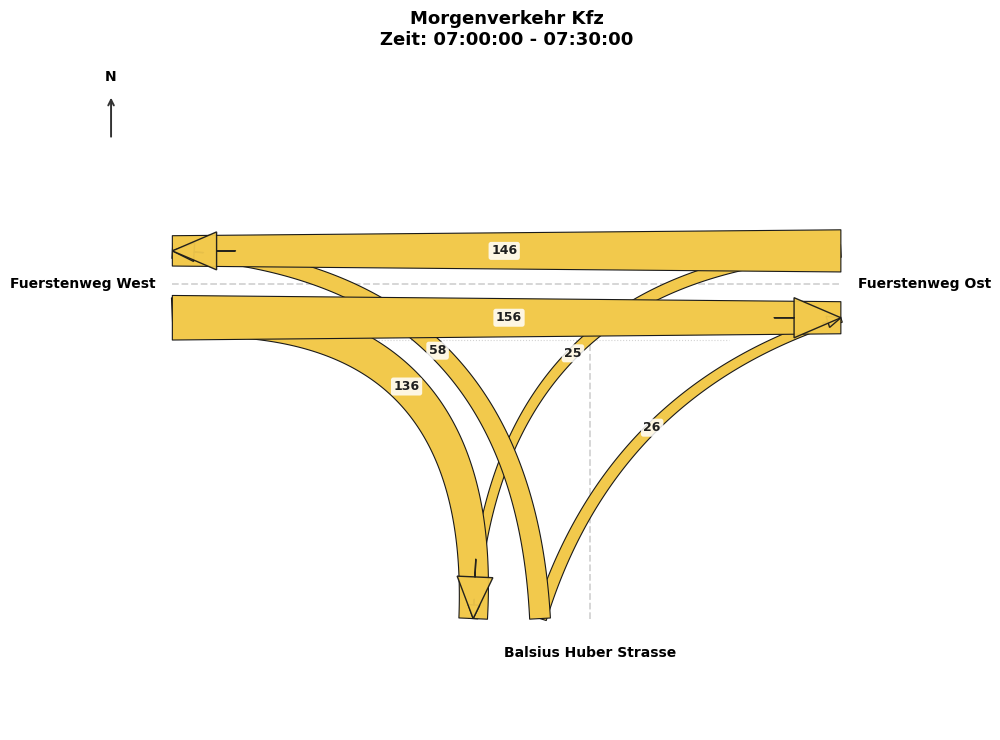

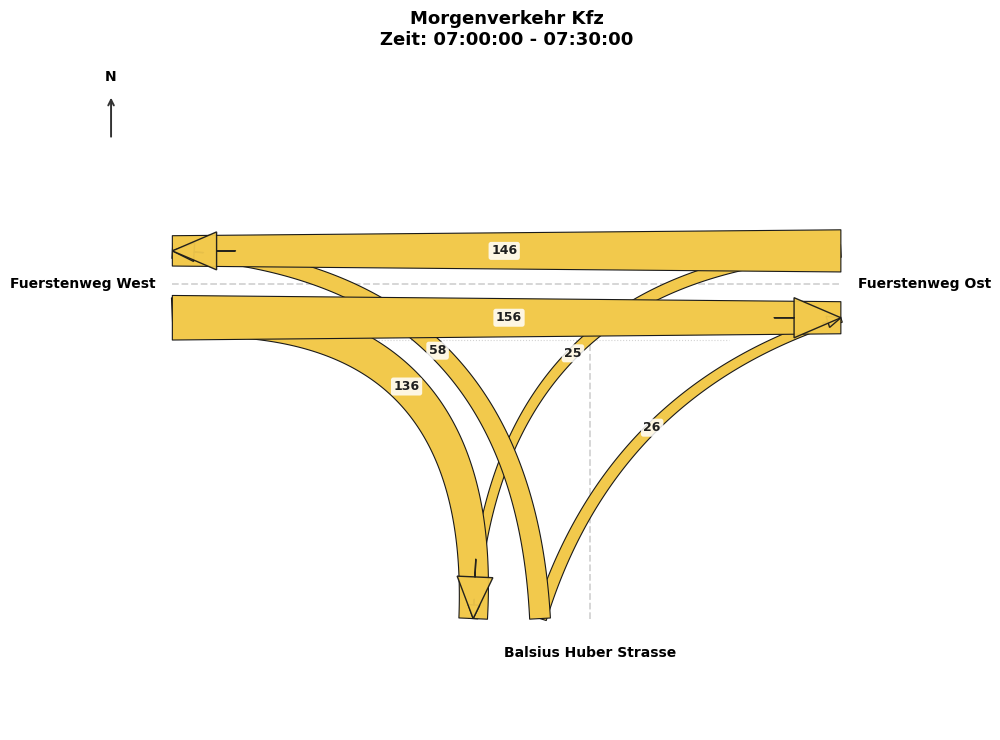

In [46]:
plot_vehicle_flows(
    df,
    vehicles=["motorrad", "pkw", "pkw_an", "lkw", "bus", "lz_slz"],
    times=["07:00:00", "07:30:00"],
    title="Morgenverkehr Kfz",
)

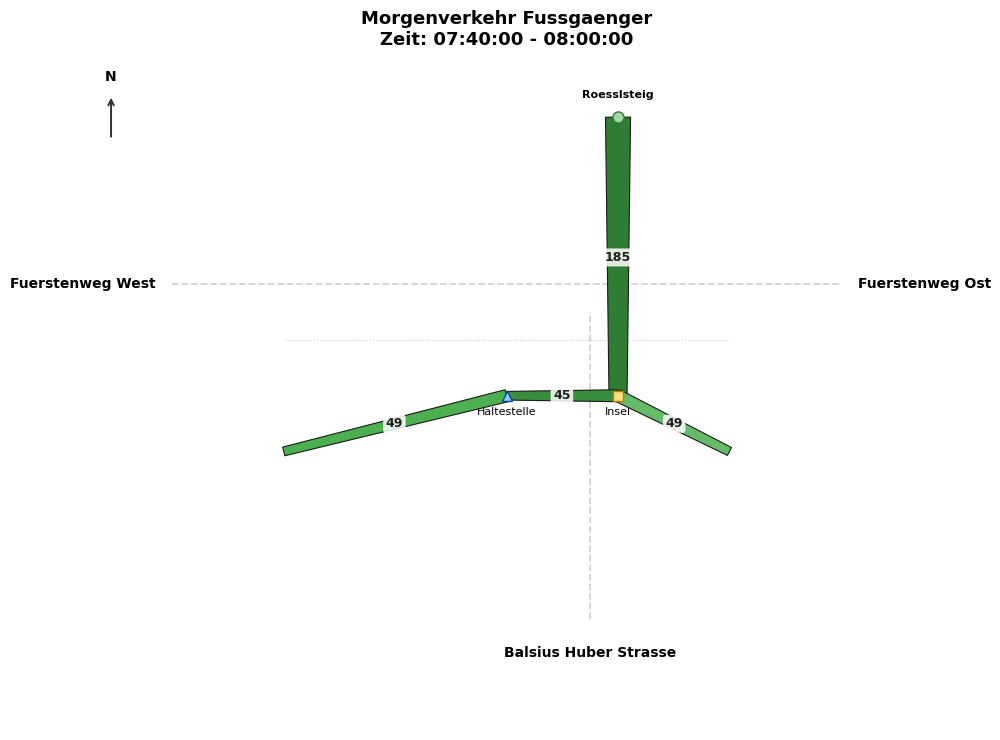

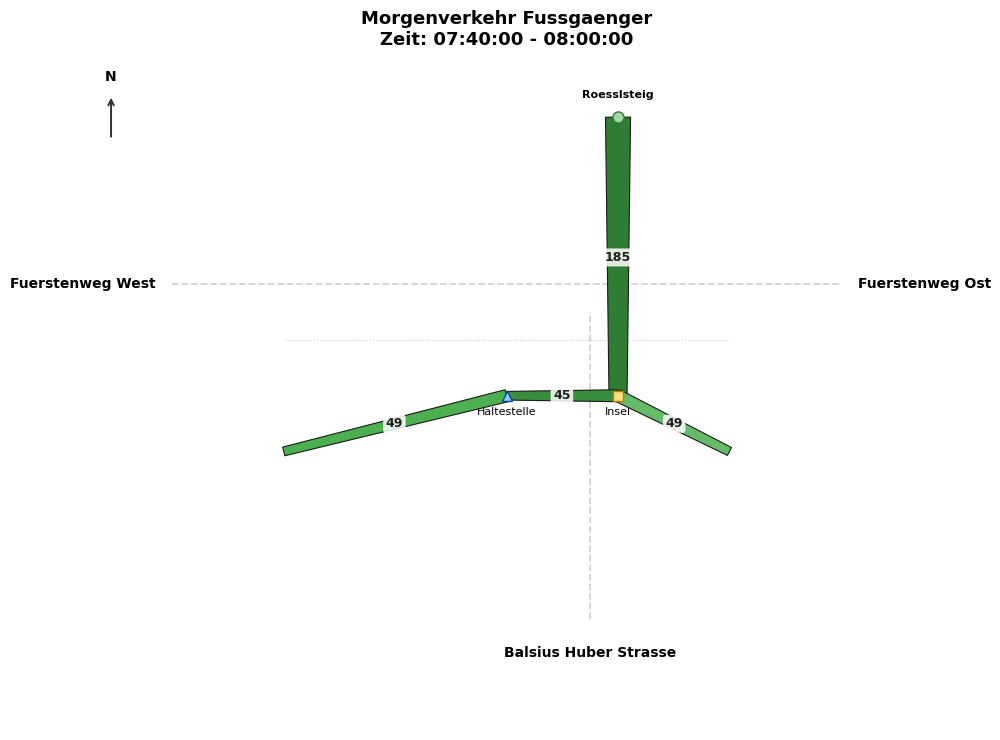

In [47]:
plot_pedestrian_flows(
    df,
    times=["07:40:00", "07:50:00", "08:00:00"],
    title="Morgenverkehr Fussgaenger",
)

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Verkehrsauswertung (alles auf einer Achse)\nZeit: 07:40:00 - 08:00:00'}>)

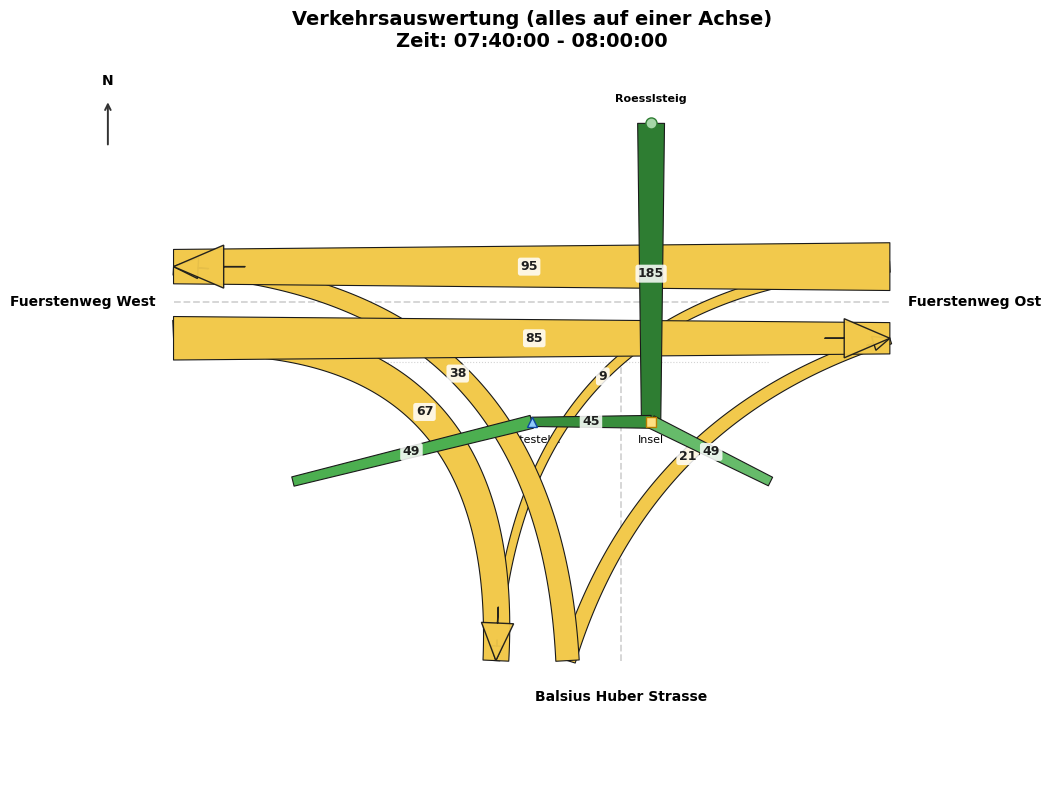

In [48]:
plot_combined_same_axes(
    df,
    times=["07:40:00", "07:50:00", "08:00:00"],
    vehicles=["motorrad", "pkw", "pkw_an", "lkw", "bus", "lz_slz"],
    figsize=(12, 8),
)